# Урок 15.8. Много переменных: частные производные и градиент

**Интерактивная версия:** `lessons/lesson_15_8/web/index.html`

После урока вы сможете:

- читать карту высот функции двух переменных, строить линии уровня и срезы, проверять предел по разным путям;
- находить частные производные по правилу «заморозки» и численно, вычислять смешанные производные;
- строить касательную плоскость и отличать частные производные от дифференцируемости;
- вычислять градиент и производную по направлению $D_{\mathbf u} f = \nabla f \cdot \mathbf u$;
- применять цепное правило и матрицу Якоби (softmax: градиент $\mathbf p - \mathbf y$);
- классифицировать критические точки гессианом, строить квадратичное приближение;
- объяснять устойчивость градиентного спуска, роль числа обусловленности и шаг Ньютона $-H^{-1}\nabla f$;
- выводить псевдо-остатки как антиградиент по прогнозам и объяснять дерево как проекцию антиградиента.

Разделы ноутбука идут в том же порядке, что и 26 шагов урока. Каждое утверждение проверяется числом,
а ключевые — сверкой с `numpy`, `scipy`, `scikit-learn`, XGBoost, LightGBM и учебной библиотекой `gbcourse`.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize

from gbcourse import datasets
from gbcourse.boosting import GBRegressor
from gbcourse.plotting import use_course_style
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE, VIOLET, cmap_sequential

use_course_style()
CMAP = cmap_sequential().reversed()   # низины — тёмные, как на картах урока


def grad_num(f, p, eps=1e-6):
    """Градиент центральными разностями: каждая координата сдвигается отдельно."""
    p = np.asarray(p, dtype=float)
    g = np.zeros_like(p)
    for i in range(len(p)):
        e = np.zeros_like(p)
        e[i] = eps
        g[i] = (f(p + e) - f(p - e)) / (2 * eps)
    return g


def hess_num(f, p, eps=1e-4):
    """Гессиан смешанными разностями."""
    p = np.asarray(p, dtype=float)
    n = len(p)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei, ej = np.eye(n)[i] * eps, np.eye(n)[j] * eps
            H[i, j] = (f(p + ei + ej) - f(p + ei - ej) - f(p - ei + ej) + f(p - ei - ej)) / (4 * eps**2)
    return H

## 1. Функция многих переменных: таблица с двумя входами

Площадь $S(a, b) = ab$, модель цены $P(s, d) = 2 + 0.1s - 0.4d$, ИМТ $m/h^2$ и потери прямой на шести квартирах
$L(w, b)$ — всё это функции двух переменных.

In [2]:
toy_X, toy_y = datasets.toy_regression()
x_flat = toy_X[:, 0]
print("площади:", x_flat, " цены:", toy_y)
L_wb = lambda w, b: np.mean((toy_y - w * x_flat - b) ** 2)  # noqa: E731
print("S(3, 4) =", 3 * 4, " P(60, 5) =", 2 + 0.1 * 60 - 0.4 * 5, " ИМТ(70, 1.75) =", round(70 / 1.75**2, 2))
w_opt, b_opt = np.polyfit(x_flat, toy_y, 1)
print(f"L(0, 0) = {L_wb(0, 0):.2f};  лучшая прямая w = {w_opt:.3f}, b = {b_opt:.3f}, L = {L_wb(w_opt, b_opt):.3f}")
assert abs(L_wb(0, 0) - 46.6667) < 1e-3 and abs(L_wb(w_opt, b_opt) - 0.9143) < 1e-3

# таблица значений ИМТ: строки — рост, столбцы — масса
for h in [1.6, 1.75, 1.9]:
    print(f"h = {h}:", "  ".join(f"{m / h**2:5.1f}" for m in [50, 70, 90, 110]))

площади: [1. 2. 3. 4. 5. 6.]  цены: [ 2.  4.  3.  7.  9. 11.]
S(3, 4) = 12  P(60, 5) = 6.0  ИМТ(70, 1.75) = 22.86
L(0, 0) = 46.67;  лучшая прямая w = 1.829, b = -0.400, L = 0.914
h = 1.6:  19.5   27.3   35.2   43.0
h = 1.75:  16.3   22.9   29.4   35.9
h = 1.9:  13.9   19.4   24.9   30.5


## 2–3. Поверхности и карты высот

Слева — поверхность $z = f(x, y)$, справа — карта высот. Линии уровня проведены с равным шагом по высоте:
где они гуще, склон круче.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


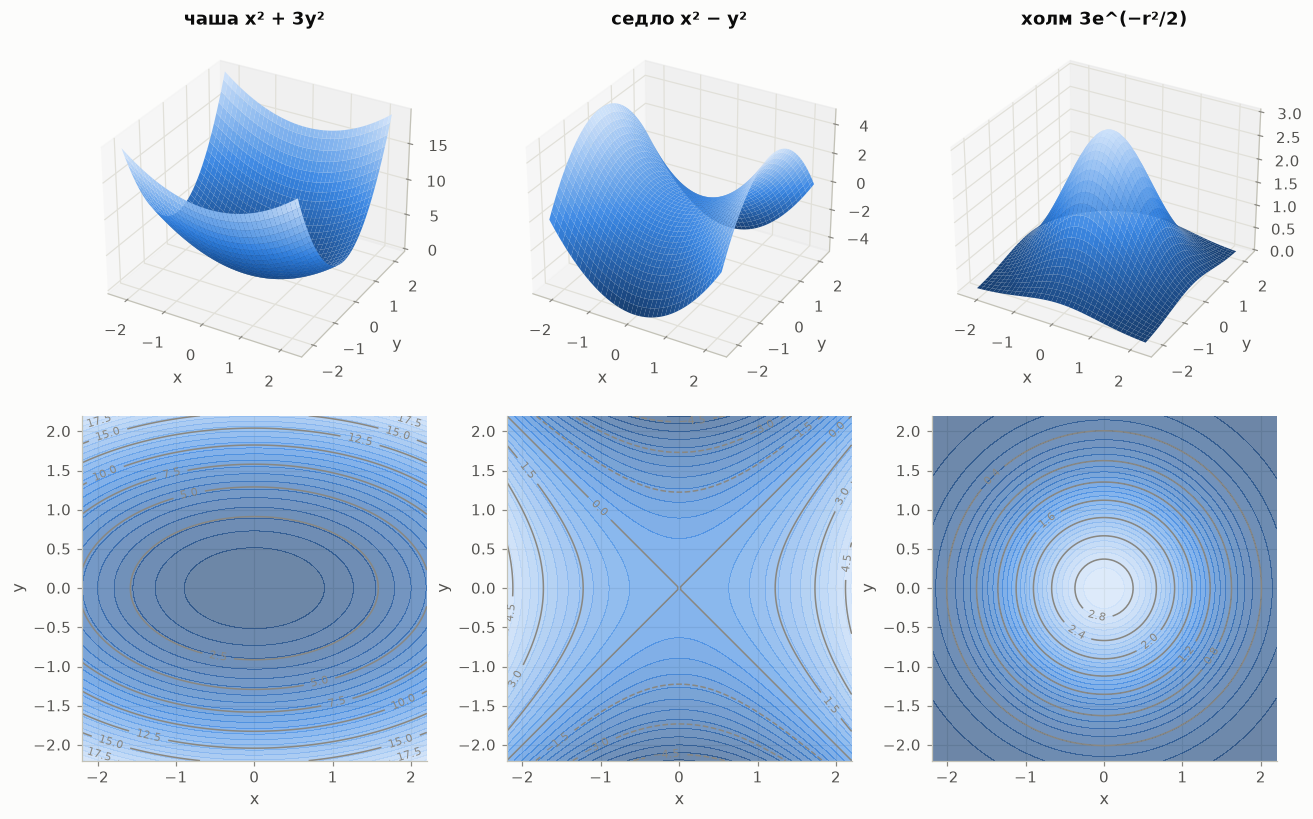

In [3]:
SURF = {
    "чаша x² + 3y²": lambda x, y: x**2 + 3 * y**2,
    "седло x² − y²": lambda x, y: x**2 - y**2,
    "холм 3e^(−r²/2)": lambda x, y: 3 * np.exp(-(x**2 + y**2) / 2),
}
Xg, Yg = np.meshgrid(np.linspace(-2.2, 2.2, 120), np.linspace(-2.2, 2.2, 120))
fig = plt.figure(figsize=(12, 7.6))
for k, (name, fn) in enumerate(SURF.items()):
    Z = fn(Xg, Yg)
    ax = fig.add_subplot(2, 3, k + 1, projection="3d")
    ax.plot_surface(Xg, Yg, Z, cmap=CMAP, linewidth=0, alpha=0.95)
    ax.set(title=name, xlabel="x", ylabel="y")
    ax2 = fig.add_subplot(2, 3, k + 4)
    ax2.contourf(Xg, Yg, Z, levels=30, cmap=CMAP, alpha=0.6)
    cs = ax2.contour(Xg, Yg, Z, levels=8, colors=MUTED, linewidths=1)
    ax2.clabel(cs, fontsize=7)
    ax2.set(aspect="equal", xlabel="x", ylabel="y")
plt.tight_layout()
plt.show()

Линии уровня круглой чаши $x^2 + y^2 = c$ — окружности радиуса $\sqrt c$: при равном шаге по $c$ кольца сближаются.

In [4]:
radii = np.sqrt(np.array([1, 2, 3, 4]))
print("радиусы колец для c = 1, 2, 3, 4:", radii.round(3), " промежутки:", np.diff(radii).round(3))

радиусы колец для c = 1, 2, 3, 4: [1.    1.414 1.732 2.   ]  промежутки: [0.414 0.318 0.268]


## 4. Срезы

Срез $y = 1$ у $x^2 + 3y^2$ — парабола $x^2 + 3$, срез $x = 1$ — $1 + 3y^2$. Срез седла по диагонали — нуль.

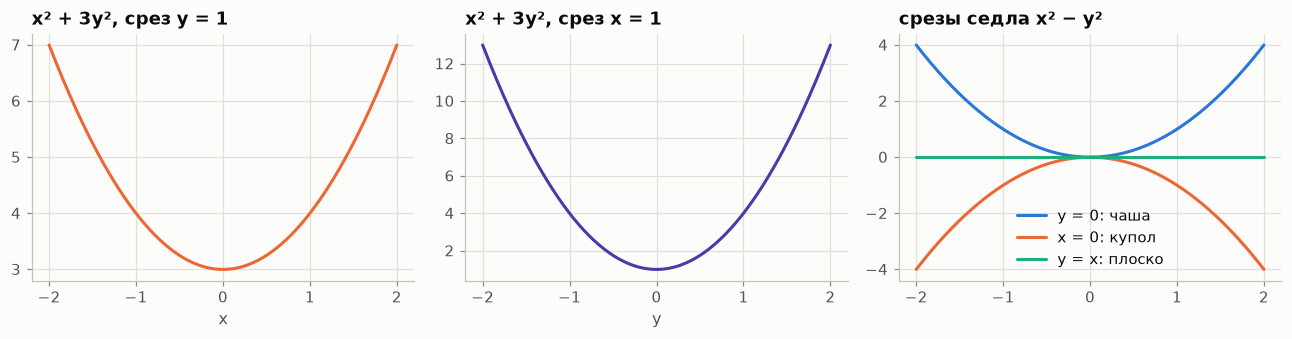

In [5]:
t = np.linspace(-2, 2, 200)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
axes[0].plot(t, t**2 + 3, color=ORANGE)
axes[0].set(title="x² + 3y², срез y = 1", xlabel="x")
axes[1].plot(t, 1 + 3 * t**2, color=VIOLET)
axes[1].set(title="x² + 3y², срез x = 1", xlabel="y")
axes[2].plot(t, t**2 - 0 * t, color=BLUE, label="y = 0: чаша")
axes[2].plot(t, -(t**2), color=ORANGE, label="x = 0: купол")
axes[2].plot(t, t**2 - t**2, color=AQUA, label="y = x: плоско")
axes[2].set(title="срезы седла x² − y²")
axes[2].legend()
plt.tight_layout()
plt.show()

## 5. Предел по разным путям

In [6]:
f_a = lambda x, y: x * y / (x**2 + y**2)        # noqa: E731
f_b = lambda x, y: x**2 * y / (x**4 + y**2)     # noqa: E731
f_c = lambda x, y: x**2 * y / (x**2 + y**2)     # noqa: E731
print("   x      | xy/(x²+y²): y=0   y=x    y=−x | x²y/(x⁴+y²): y=x   y=x² | x²y/(x²+y²): y=x   y=x²")
for x in [0.1, 0.01, 0.001]:
    print(f"{x:9.3g} | {f_a(x, 0 * x):14.4f} {f_a(x, x):6.3f} {f_a(x, -x):6.3f} |"
          f" {f_b(x, x):16.5f} {f_b(x, x * x):6.3f} | {f_c(x, x):16.5f} {f_c(x, x * x):7.5f}")
assert abs(f_b(1e-3, 1e-6) - 0.5) < 1e-9 and abs(f_b(1e-3, 1e-3)) < 2e-3

   x      | xy/(x²+y²): y=0   y=x    y=−x | x²y/(x⁴+y²): y=x   y=x² | x²y/(x²+y²): y=x   y=x²
      0.1 |         0.0000  0.500 -0.500 |          0.09901  0.500 |          0.05000 0.00990
     0.01 |         0.0000  0.500 -0.500 |          0.01000  0.500 |          0.00500 0.00010
    0.001 |         0.0000  0.500 -0.500 |          0.00100  0.500 |          0.00050 0.00000


## 6–7. Частные производные: по определению и по правилу «заморозки»

In [7]:
f = lambda p: p[0] ** 2 + 3 * p[1] ** 2  # noqa: E731
for h in [0.1, 0.01, 0.001]:
    qx = (f([1 + h, 1]) - f([1, 1])) / h
    qy = (f([1, 1 + h]) - f([1, 1])) / h
    print(f"h = {h:<6} [f(1+h,1) − f]/h = {qx:.4f}   [f(1,1+h) − f]/h = {qy:.4f}")

h = 0.1    [f(1+h,1) − f]/h = 2.1000   [f(1,1+h) − f]/h = 6.3000
h = 0.01   [f(1+h,1) − f]/h = 2.0100   [f(1,1+h) − f]/h = 6.0300
h = 0.001  [f(1+h,1) − f]/h = 2.0010   [f(1,1+h) − f]/h = 6.0030


Формулы из виджета «заморозка» против центральных разностей:

In [8]:
CASES = {
    "x²y":          (lambda p: p[0]**2 * p[1], lambda x, y: [2 * x * y, x**2], (1, 2)),
    "x·e^(xy)":     (lambda p: p[0] * np.exp(p[0] * p[1]), lambda x, y: [(1 + x * y) * np.exp(x * y), x**2 * np.exp(x * y)], (1, 0.5)),
    "ln(x² + y²)":  (lambda p: np.log(p[0]**2 + p[1]**2), lambda x, y: [2 * x / (x**2 + y**2), 2 * y / (x**2 + y**2)], (1, 2)),
    "m/h² (ИМТ)":   (lambda p: p[0] / p[1]**2, lambda m, h: [1 / h**2, -2 * m / h**3], (70, 1.75)),
    "x^y":          (lambda p: p[0] ** p[1], lambda x, y: [y * x ** (y - 1), x**y * np.log(x)], (2, 3)),
    "√(x² + y²)":   (lambda p: np.hypot(p[0], p[1]), lambda x, y: [x / np.hypot(x, y), y / np.hypot(x, y)], (3, 4)),
    "(5 − 2w − b)²": (lambda p: (5 - 2 * p[0] - p[1]) ** 2, lambda w, b: [-4 * (5 - 2 * w - b), -2 * (5 - 2 * w - b)], (1, 0)),
}
for name, (fn, d, pt) in CASES.items():
    exact = np.array(d(*pt), dtype=float)
    num = grad_num(fn, pt)
    print(f"{name:14} в {pt}: формула {exact.round(5)}, численно {num.round(5)}")
    assert np.allclose(exact, num, rtol=1e-6, atol=1e-6)

x²y            в (1, 2): формула [4. 1.], численно [4. 1.]
x·e^(xy)       в (1, 0.5): формула [2.47308 1.64872], численно [2.47308 1.64872]
ln(x² + y²)    в (1, 2): формула [0.4 0.8], численно [0.4 0.8]
m/h² (ИМТ)     в (70, 1.75): формула [  0.32653 -26.12245], численно [  0.32653 -26.12245]
x^y            в (2, 3): формула [12.       5.54518], численно [12.       5.54518]
√(x² + y²)     в (3, 4): формула [0.6 0.8], численно [0.6 0.8]
(5 − 2w − b)²  в (1, 0): формула [-12.  -6.], численно [-12.  -6.]


## 8. Численная частная производная: выбор шага

h = 1e-03: вперёд 1.0e-03, центральная 2.4e-07
h = 1e-05: вперёд 1.0e-05, центральная 2.3e-11
h = 1e-10: вперёд 1.7e-07, центральная 1.7e-07


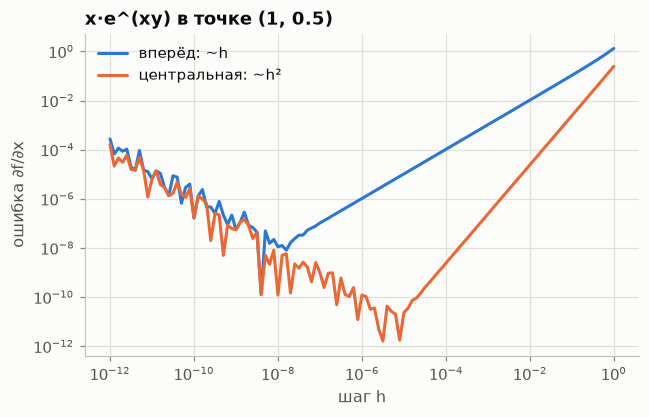

In [9]:
g_xe = lambda x, y: x * np.exp(x * y)  # noqa: E731
exact = 1.5 * np.exp(0.5)
hs = np.logspace(-12, 0, 121)
err_f = np.abs((g_xe(1 + hs, 0.5) - g_xe(1, 0.5)) / hs - exact)
err_c = np.abs((g_xe(1 + hs, 0.5) - g_xe(1 - hs, 0.5)) / (2 * hs) - exact)
for h in [1e-3, 1e-5, 1e-10]:
    i = np.argmin(np.abs(hs - h))
    print(f"h = {h:.0e}: вперёд {err_f[i]:.1e}, центральная {err_c[i]:.1e}")
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.loglog(hs, np.maximum(err_f, 1e-17), color=BLUE, label="вперёд: ~h")
ax.loglog(hs, np.maximum(err_c, 1e-17), color=ORANGE, label="центральная: ~h²")
ax.set(xlabel="шаг h", ylabel="ошибка ∂f/∂x", title="x·e^(xy) в точке (1, 0.5)")
ax.legend()
plt.show()

## 9. Смешанные производные и теорема Шварца

In [10]:
fxy_exact = 1 * (2 + 0.5) * np.exp(0.5)   # x(2 + xy)e^(xy) в (1, 0.5)
H_num = hess_num(lambda p: p[0] * np.exp(p[0] * p[1]), (1, 0.5))
print("x·e^(xy): f_xy по формуле", round(fxy_exact, 5), " гессиан численно:\n", H_num.round(4))
print("x³y² в (1, 2): f_xy = 6x²y =", 6 * 1 * 2)

# контрпример: смешанные производные в нуле разные
pe = lambda x, y: 0.0 if x == 0 and y == 0 else x * y * (x * x - y * y) / (x * x + y * y)  # noqa: E731
e = 1e-6
fx_on = lambda y: (pe(e, y) - pe(-e, y)) / (2 * e)  # noqa: E731
fy_on = lambda x: (pe(x, e) - pe(x, -e)) / (2 * e)  # noqa: E731
d = 1e-3
print("контрпример: f_xy(0, 0) ≈", round((fx_on(d) - fx_on(-d)) / (2 * d), 4), " f_yx(0, 0) ≈", round((fy_on(d) - fy_on(-d)) / (2 * d), 4))

x·e^(xy): f_xy по формуле 4.1218  гессиан численно:
 [[2.0609 4.1218]
 [4.1218 1.6487]]
x³y² в (1, 2): f_xy = 6x²y = 12
контрпример: f_xy(0, 0) ≈ -1.0  f_yx(0, 0) ≈ 1.0


## 10. Касательная плоскость: ошибка ~ρ² — и конус, где её нет

√(x²+y²) около (3, 4): оценка f(3.02, 3.97) ≈ 4.9879999999999995  точно 4.98812
наклон на лог-лог шкале: холм 2.00 (≈ 2), конус в вершине 1.00 (≈ 1)


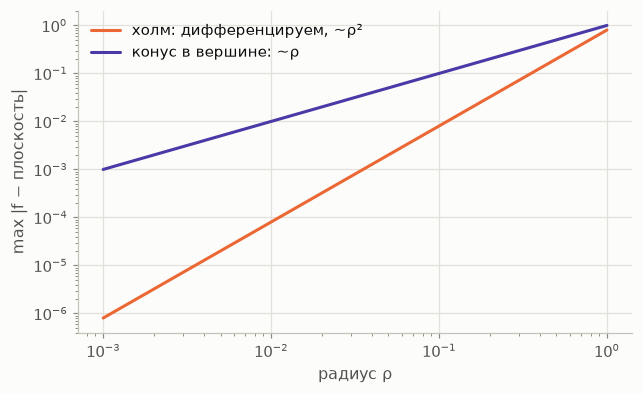

In [11]:
r_fn = lambda x, y: np.hypot(x, y)  # noqa: E731
print("√(x²+y²) около (3, 4): оценка f(3.02, 3.97) ≈", 5 + 0.6 * 0.02 - 0.8 * 0.03, " точно", round(r_fn(3.02, 3.97), 5))
rhos = np.logspace(-3, 0, 31)
ang = np.linspace(0, 2 * np.pi, 64, endpoint=False)


def plane_error(fn, a, g, rho):
    P = a + rho * np.c_[np.cos(ang), np.sin(ang)]
    return np.abs(fn(P[:, 0], P[:, 1]) - (fn(*a) + (P - a) @ g)).max()


hill = lambda x, y: 3 * np.exp(-(x**2 + y**2) / 2)  # noqa: E731
a = np.array([1.0, 0.5])
g_hill = grad_num(lambda p: hill(*p), a)
err_hill = [plane_error(hill, a, g_hill, r) for r in rhos]
err_cone = [plane_error(r_fn, np.zeros(2), np.zeros(2), r) for r in rhos]
slope_hill = np.polyfit(np.log10(rhos[:10]), np.log10(err_hill[:10]), 1)[0]
slope_cone = np.polyfit(np.log10(rhos), np.log10(err_cone), 1)[0]
print(f"наклон на лог-лог шкале: холм {slope_hill:.2f} (≈ 2), конус в вершине {slope_cone:.2f} (≈ 1)")
assert abs(slope_hill - 2) < 0.05 and abs(slope_cone - 1) < 0.01
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.loglog(rhos, err_hill, color=ORANGE, label="холм: дифференцируем, ~ρ²")
ax.loglog(rhos, err_cone, color=VIOLET, label="конус в вершине: ~ρ")
ax.set(xlabel="радиус ρ", ylabel="max |f − плоскость|")
ax.legend()
plt.show()

## 11–13. Векторы, градиент, производная по направлению

u·v = 5.0  угол = 45.0 °
u = [0.6 0.8]: ∇f·u = +6.0000, по определению +6.0000
u = [ 0.7071 -0.7071]: ∇f·u = -2.8284, по определению -2.8284
u = [0.3162 0.9487]: ∇f·u = +6.3246, по определению +6.3246
max D_u f = 6.3244 = |∇f| = 6.3246 при угле 72°


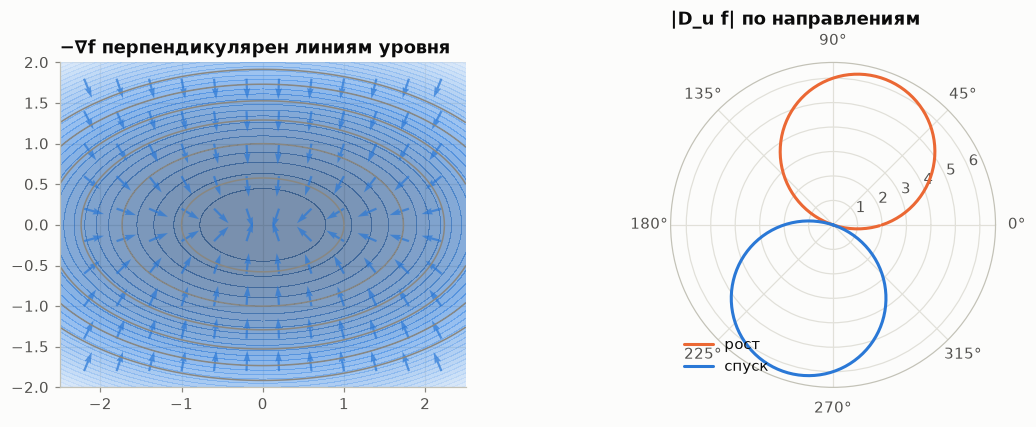

In [12]:
u, v = np.array([2.0, 1.0]), np.array([1.0, 3.0])
print("u·v =", u @ v, " угол =", np.degrees(np.arccos(u @ v / np.linalg.norm(u) / np.linalg.norm(v))).round(2), "°")
g = np.array([2.0, 6.0])     # ∇(x² + 3y²) в (1, 1)
for uu in [np.array([0.6, 0.8]), np.array([1, -1]) / np.sqrt(2), g / np.linalg.norm(g)]:
    by_limit = (f(np.array([1.0, 1.0]) + 1e-7 * uu) - f([1, 1])) / 1e-7
    print(f"u = {uu.round(4)}: ∇f·u = {g @ uu:+.4f}, по определению {by_limit:+.4f}")
angles = np.radians(np.arange(360))
D = np.c_[np.cos(angles), np.sin(angles)] @ g
print(f"max D_u f = {D.max():.4f} = |∇f| = {np.linalg.norm(g):.4f} при угле {np.degrees(angles[D.argmax()]):.0f}°")

fig = plt.figure(figsize=(11, 4))
ax = fig.add_subplot(1, 2, 1)
Xb, Yb = np.meshgrid(np.linspace(-2.5, 2.5, 200), np.linspace(-2, 2, 160))
ax.contourf(Xb, Yb, Xb**2 + 3 * Yb**2, levels=30, cmap=CMAP, alpha=0.55)
ax.contour(Xb, Yb, Xb**2 + 3 * Yb**2, levels=[1, 3, 5, 7, 9, 11], colors=MUTED, linewidths=1)
QX, QY = np.meshgrid(np.linspace(-2.2, 2.2, 12), np.linspace(-1.8, 1.8, 10))
GX, GY = 2 * QX, 6 * QY
N = np.hypot(GX, GY) + 1e-12
ax.quiver(QX, QY, -GX / N, -GY / N, color=BLUE, alpha=0.7)
ax.set(aspect="equal", title="−∇f перпендикулярен линиям уровня")
ax2 = fig.add_subplot(1, 2, 2, projection="polar")
ax2.plot(angles, np.maximum(D, 0), color=ORANGE, label="рост")
ax2.plot(angles, np.maximum(-D, 0), color=BLUE, label="спуск")
ax2.set_title("|D_u f| по направлениям")
ax2.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 14. Градиент перпендикулярен линии уровня; густота линий

In [13]:
tt = np.linspace(0, 2 * np.pi, 200001)
EX, EY = 2 * np.cos(tt), (2 / np.sqrt(3)) * np.sin(tt)      # эллипс x² + 3y² = 4
i = np.argmin((EX - 1) ** 2 + (EY - 1) ** 2)
tangent = np.array([EX[i + 1] - EX[i - 1], EY[i + 1] - EY[i - 1]])
gg = np.array([2 * EX[i], 6 * EY[i]])
print("cos(касательная, ∇f) =", f"{tangent @ gg / np.linalg.norm(tangent) / np.linalg.norm(gg):.1e}")
# расстояние до соседнего уровня (Δc = 2) вдоль градиента из (1, 1)
ug = g / np.linalg.norm(g)
dist = optimize.brentq(lambda s: f(np.array([1.0, 1.0]) + s * ug) - 6, 0, 1)
print(f"Δc/|∇f| = {2 / np.linalg.norm(g):.4f}, на самом деле {dist:.4f}")

cos(касательная, ∇f) = -3.8e-13
Δc/|∇f| = 0.3162, на самом деле 0.2812


## 15. Цепное правило

In [14]:
tq = np.pi / 4
x_, y_ = np.cos(tq), np.sin(tq)
vx, vy = -np.sin(tq), np.cos(tq)
chain = 2 * x_ * vx + 6 * y_ * vy
direct = (f([np.cos(tq + 1e-6), np.sin(tq + 1e-6)]) - f([np.cos(tq - 1e-6), np.sin(tq - 1e-6)])) / 2e-6
print(f"x² + 3y² на окружности при t = π/4: вклады {2 * x_ * vx:.3f} и {6 * y_ * vy:.3f}, сумма {chain:.4f}, напрямую {direct:.4f}")
assert abs(chain - 2) < 1e-9 and abs(direct - 2) < 1e-6

x² + 3y² на окружности при t = π/4: вклады -1.000 и 3.000, сумма 2.0000, напрямую 2.0000


## 16. Матрица Якоби softmax

In [15]:
def softmax(z):
    e_ = np.exp(z - z.max())
    return e_ / e_.sum()


z = np.array([2.0, 1.0, 0.0])
p = softmax(z)
J = np.diag(p) - np.outer(p, p)
J_num = np.array([(softmax(z + 1e-6 * np.eye(3)[j]) - softmax(z - 1e-6 * np.eye(3)[j])) / 2e-6 for j in range(3)]).T
print("p =", p.round(4))
print("Якоби по формуле:\n", J.round(4))
print("совпадает с численной:", np.allclose(J, J_num, atol=1e-8), "  суммы строк:", J.sum(1).round(12))
CE = lambda z: -np.log(softmax(z)[0])  # noqa: E731
print("∇(−ln p₁) = p − y:", (p - np.eye(3)[0]).round(4), " численно:", grad_num(CE, z).round(4))

p = [0.6652 0.2447 0.09  ]
Якоби по формуле:
 [[ 0.2227 -0.1628 -0.0599]
 [-0.1628  0.1848 -0.022 ]
 [-0.0599 -0.022   0.0819]]
совпадает с численной: True   суммы строк: [0. 0. 0.]
∇(−ln p₁) = p − y: [-0.3348  0.2447  0.09  ]  численно: [-0.3348  0.2447  0.09  ]


## 17–18. Критические точки и тест гессиана

Ищем критические точки $x^4 + y^4 - 4xy$ решением системы $\nabla f = 0$ из многих стартов (`scipy.optimize.root`),
классифицируем по собственным числам гессиана.

In [16]:
q4 = lambda p: p[0] ** 4 + p[1] ** 4 - 4 * p[0] * p[1]                         # noqa: E731
q4_grad = lambda p: np.array([4 * p[0] ** 3 - 4 * p[1], 4 * p[1] ** 3 - 4 * p[0]])  # noqa: E731
q4_hess = lambda p: np.array([[12 * p[0] ** 2, -4], [-4, 12 * p[1] ** 2]])         # noqa: E731
found = []
for sx in np.linspace(-1.6, 1.6, 7):
    for sy in np.linspace(-1.6, 1.6, 7):
        sol = optimize.root(q4_grad, [sx, sy], jac=q4_hess)
        if sol.success and not any(np.allclose(sol.x, q, atol=1e-6) for q in found):
            found.append(sol.x)
for pt in sorted(found, key=lambda q: q[0]):
    lam = np.linalg.eigvalsh(q4_hess(pt))
    kind = "седло" if lam.min() < 0 < lam.max() else "минимум" if lam.min() > 0 else "максимум"
    print(f"({pt[0]:+.4f}, {pt[1]:+.4f}): f = {q4(pt):+.3f}, λ = {lam.round(3)} → {kind}")
assert len(found) == 3

# ловушка: f_xx, f_yy > 0, но седло
Ht = np.array([[2.0, 4.0], [4.0, 2.0]])
print("x² + 4xy + y²: det H =", np.linalg.det(Ht).round(3), " λ =", np.linalg.eigvalsh(Ht))

(-1.0000, -1.0000): f = -2.000, λ = [ 8. 16.] → минимум
(+0.0000, +0.0000): f = +0.000, λ = [-4.  4.] → седло
(+1.0000, +1.0000): f = -2.000, λ = [ 8. 16.] → минимум
x² + 4xy + y²: det H = -12.0  λ = [-2.  6.]


## 19. Квадратичное приближение $e^x \cos y$ около нуля

In [17]:
ec = lambda x, y: np.exp(x) * np.cos(y)  # noqa: E731
for (x, y) in [(0.1, 0.2), (0.01, 0.02)]:
    ex_, T1, T2 = ec(x, y), 1 + x, 1 + x + 0.5 * (x * x - y * y)
    print(f"({x}, {y}): точно {ex_:.6f}, плоскость {T1} (ошибка {abs(ex_ - T1):.1e}), второй порядок {T2} (ошибка {abs(ex_ - T2):.1e})")

(0.1, 0.2): точно 1.083141, плоскость 1.1 (ошибка 1.7e-02), второй порядок 1.0850000000000002 (ошибка 1.9e-03)
(0.01, 0.02): точно 1.009848, плоскость 1.01 (ошибка 1.5e-04), второй порядок 1.00985 (ошибка 1.8e-06)


## 20. Градиентный спуск: граница устойчивости

η = 0.05  множители +0.90 и +0.70: 73 шагов
η = 0.1   множители +0.80 и +0.40: 35 шагов
η = 0.15  множители +0.70 и +0.10: 22 шагов
η = 0.25  множители +0.50 и -0.50: 12 шагов
η = 0.3   множители +0.40 и -0.80: 36 шагов
η = 0.33  множители +0.34 и -0.98: 393 шагов
η = 0.34  множители +0.32 и -1.04: расходится


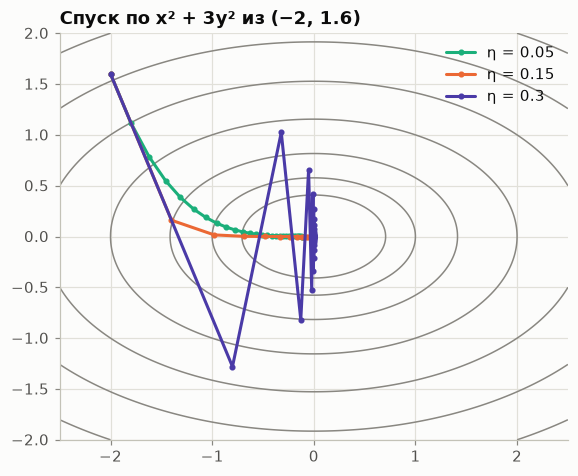

In [18]:
gradf = lambda p: np.array([2 * p[0], 6 * p[1]])  # noqa: E731


def run_gd(eta, p0=(-2.0, 1.6), tol=1e-6, max_steps=2000):
    p, k, path = np.array(p0), 0, [np.array(p0)]
    while tol < f(p) < 1e6 and k < max_steps:
        p, k = p - eta * gradf(p), k + 1
        path.append(p)
    return k, f(p), np.array(path)


for eta in [0.05, 0.1, 0.15, 0.25, 0.3, 0.33, 0.34]:
    k, fv, _ = run_gd(eta)
    print(f"η = {eta:<5} множители {1 - 2 * eta:+.2f} и {1 - 6 * eta:+.2f}: " + ("расходится" if fv >= 1e6 else f"{k} шагов"))

fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.contour(Xb, Yb, Xb**2 + 3 * Yb**2, levels=[0.5, 1, 2, 4, 7, 11, 16], colors=MUTED, linewidths=1)
for eta, c in [(0.05, AQUA), (0.15, ORANGE), (0.3, VIOLET)]:
    path = run_gd(eta)[2][:30]
    ax.plot(path[:, 0], path[:, 1], "o-", ms=3, color=c, label=f"η = {eta}")
ax.set(aspect="equal", xlim=(-2.5, 2.5), ylim=(-2, 2), title="Спуск по x² + 3y² из (−2, 1.6)")
ax.legend()
plt.show()

## 21. Овраги, число обусловленности и метод Ньютона

In [19]:
for kappa in [1, 3, 10, 30, 100]:
    Hk = np.diag([1.0, kappa])
    p0 = np.array([2.0, 1.0])
    f0 = 0.5 * p0 @ Hk @ p0
    p_, k, eta = p0.copy(), 0, 2 / (1 + kappa)
    while 0.5 * p_ @ Hk @ p_ > 1e-6 * f0:
        p_, k = p_ - eta * Hk @ p_, k + 1
    newton = p0 - np.linalg.solve(Hk, Hk @ p0)
    print(f"κ = {kappa:3}: множитель (κ−1)/(κ+1) = {(kappa - 1) / (kappa + 1):.3f}, спуск {k:3} шагов, Ньютон → {newton}")

κ =   1: множитель (κ−1)/(κ+1) = 0.000, спуск   1 шагов, Ньютон → [0. 0.]
κ =   3: множитель (κ−1)/(κ+1) = 0.500, спуск  10 шагов, Ньютон → [0. 0.]
κ =  10: множитель (κ−1)/(κ+1) = 0.818, спуск  35 шагов, Ньютон → [0. 0.]
κ =  30: множитель (κ−1)/(κ+1) = 0.935, спуск 104 шагов, Ньютон → [0. 0.]
κ = 100: множитель (κ−1)/(κ+1) = 0.980, спуск 346 шагов, Ньютон → [0. 0.]


## 22. Множители Лагранжа: аналитика против `scipy.optimize.minimize`

In [20]:
res = optimize.minimize(lambda p: -(p[0] + 2 * p[1]), [1, 0], constraints={"type": "eq", "fun": lambda p: p[0] ** 2 + p[1] ** 2 - 1})
print("max x + 2y на окружности:", res.x.round(4), " f =", round(-res.fun, 4), " (аналитически (1, 2)/√5, √5 =", round(np.sqrt(5), 4), ")")
res2 = optimize.minimize(lambda p: p[0] ** 2 + 3 * p[1] ** 2, [0, 0], constraints={"type": "eq", "fun": lambda p: p[0] + p[1] - 1})
print("min x² + 3y² на x + y = 1:", res2.x.round(4), " f =", round(res2.fun, 4), " λ = 2x =", round(2 * res2.x[0], 4))
assert np.allclose(res.x, np.array([1, 2]) / np.sqrt(5), atol=1e-4) and np.allclose(res2.x, [0.75, 0.25], atol=1e-4)

max x + 2y на окружности: [0.4472 0.8944]  f = 2.2361  (аналитически (1, 2)/√5, √5 = 2.2361 )
min x² + 3y² на x + y = 1: [0.75 0.25]  f = 0.75  λ = 2x = 1.5


## 23. Потери как функция параметров: градиентный спуск для прямой

Сверка с `numpy.polyfit` и `sklearn.linear_model.LinearRegression`; центрирование признака уменьшает
число обусловленности с 87.6 до 2.9.

In [21]:
from sklearn.linear_model import LinearRegression  # noqa: E402

print("∇L(0, 0) =", grad_num(lambda q: L_wb(*q), [0, 0]).round(4))


def fit_gd(xx, eta, tol=1e-6, steps=20000):
    w = b = 0.0
    L_opt = np.mean((toy_y - np.polyval(np.polyfit(xx, toy_y, 1), xx)) ** 2)
    for k in range(steps):
        r = toy_y - (w * xx + b)
        if np.mean(r**2) - L_opt < tol:
            return w, b, k
        w, b = w + eta * 2 * np.mean(xx * r), b + eta * 2 * np.mean(r)
        if abs(w) > 1e8:
            return w, b, -1
    return w, b, steps


for xx, eta, name in [(x_flat, 0.05, "исходный x"), (x_flat, 0.1, "исходный x"), (x_flat - 3.5, 0.3, "x − 3.5")]:
    w, b, k = fit_gd(xx, eta)
    Hm = 2 * np.array([[np.mean(xx**2), np.mean(xx)], [np.mean(xx), 1]])
    lam = np.linalg.eigvalsh(Hm)
    print(f"{name:10} η = {eta}: " + ("расходится" if k < 0 else f"w = {w:.4f}, b = {b:.4f}, {k} шагов") + f";  κ = {lam[1] / lam[0]:.2f}, η < {2 / lam[1]:.4f}")
lr = LinearRegression().fit(toy_X, toy_y)
print("sklearn:", round(lr.coef_[0], 4), round(lr.intercept_, 4))

∇L(0, 0) = [-52.6667 -12.    ]
исходный x η = 0.05: w = 1.8280, b = -0.3978, 318 шагов;  κ = 87.60, η < 0.0626
исходный x η = 0.1: расходится;  κ = 87.60, η < 0.0626
x − 3.5    η = 0.3: w = 1.8280, b = 6.0000, 28 шагов;  κ = 2.92, η < 0.3429
sklearn: 1.8286 -0.4


## 24. Градиент по вектору прогнозов — псевдо-остатки

Сверяем аналитические псевдо-остатки разных потерь с численным градиентом суммы потерь по вектору прогнозов.

In [22]:
yv = np.array([3.0, 1.0, 2.0])
Fv = np.array([-2.0, 4.0, 2.5])
LOSSES = {
    "MSE":   (lambda F: 0.5 * np.sum((yv - F) ** 2), lambda F: yv - F),
    "Хьюбер": (lambda F: np.sum(np.where(np.abs(yv - F) <= 1, 0.5 * (yv - F) ** 2, np.abs(yv - F) - 0.5)), lambda F: np.clip(yv - F, -1, 1)),
    "Пуассон": (lambda F: np.sum(np.exp(F) - yv * F), lambda F: yv - np.exp(F)),
}
for name, (Lf, neg_g) in LOSSES.items():
    print(f"{name:8} псевдо-остатки {neg_g(Fv).round(4)},  −численный градиент {(-grad_num(Lf, Fv)).round(4)}")
    assert np.allclose(neg_g(Fv), -grad_num(Lf, Fv), atol=1e-5)
yc, Fc = np.array([1.0, 0.0]), np.zeros(2)
LL = lambda F: np.sum(np.log1p(np.exp(-F)) * yc + np.log1p(np.exp(F)) * (1 - yc))  # noqa: E731
print("log-loss, y = (1, 0), F = 0: y − p =", yc - 0.5, " численно", (-grad_num(LL, Fc)).round(6))

MSE      псевдо-остатки [ 5.  -3.  -0.5],  −численный градиент [ 5.  -3.  -0.5]
Хьюбер   псевдо-остатки [ 1.  -1.  -0.5],  −численный градиент [ 1.  -1.  -0.5]
Пуассон  псевдо-остатки [  2.8647 -53.5982 -10.1825],  −численный градиент [  2.8647 -53.5982 -10.1825]
log-loss, y = (1, 0), F = 0: y − p = [ 0.5 -0.5]  численно [ 0.5 -0.5]


## 25. Шаг деревом: проекция антиградиента; сверка с `gbcourse` и scikit-learn

In [23]:
F0 = np.full(6, toy_y.mean())
r = toy_y - F0
print("антиградиент:", r, " потери:", 0.5 * r @ r)
for thr in (x_flat[:-1] + x_flat[1:]) / 2:
    h = np.where(x_flat <= thr, r[x_flat <= thr].mean(), r[x_flat > thr].mean())
    cos = h @ r / np.linalg.norm(h) / np.linalg.norm(r)
    print(f"порог {thr}: потери {0.5 * np.sum((r - h) ** 2):5.1f}, cos = {cos:.4f}, (r − h)·h = {(r - h) @ h:+.1e}, ½|h|² = {0.5 * h @ h:.1f}")

loss = lambda F: 0.5 * np.sum((toy_y - F) ** 2)  # noqa: E731
from sklearn.ensemble import GradientBoostingRegressor  # noqa: E402

for nu in (1.0, 0.5):
    ours = [loss(GBRegressor(n_estimators=M, learning_rate=nu, max_depth=1).fit(toy_X, toy_y).predict(toy_X)) if M else loss(F0) for M in range(9)]
    sk = GradientBoostingRegressor(n_estimators=8, learning_rate=nu, max_depth=1).fit(toy_X, toy_y)
    skl = [loss(F0)] + [loss(Fp) for Fp in sk.staged_predict(toy_X)]
    print(f"ν = {nu}: gbcourse {np.round(ours, 3)}")
    print(f"        sklearn  {np.round(skl, 3)}")
    assert np.allclose(ours, skl, atol=1e-9)
m1 = GBRegressor(n_estimators=1, learning_rate=1.0, max_depth=1).fit(toy_X, toy_y)
print("прогноз пня для новой квартиры x = 4.5:", m1.predict(np.array([[4.5]]))[0], " (шаг «по точкам» такого правила не даёт)")

антиградиент: [-4. -2. -3.  1.  3.  5.]  потери: 32.0
порог 1.5: потери  22.4, cos = 0.5477, (r − h)·h = +1.3e-15, ½|h|² = 9.6
порог 2.5: потери  18.5, cos = 0.6495, (r − h)·h = +0.0e+00, ½|h|² = 13.5
порог 3.5: потери   5.0, cos = 0.9186, (r − h)·h = +0.0e+00, ½|h|² = 27.0
порог 4.5: потери   8.0, cos = 0.8660, (r − h)·h = +0.0e+00, ½|h|² = 24.0
порог 5.5: потери  17.0, cos = 0.6847, (r − h)·h = +0.0e+00, ½|h|² = 15.0
ν = 1.0: gbcourse [32.     5.     2.6    2.12   1.52   1.28   0.74   0.47   0.335]
        sklearn  [32.     5.     2.6    2.12   1.52   1.28   0.74   0.47   0.335]
ν = 0.5: gbcourse [32.    11.75   4.719  2.441  1.216  0.686  0.455  0.337  0.293]
        sklearn  [32.    11.75   4.719  2.441  1.216  0.686  0.455  0.337  0.293]
прогноз пня для новой квартиры x = 4.5: 9.0  (шаг «по точкам» такого правила не даёт)


## 26. Гессиан по прогнозам: диагональ — и что берут библиотеки для softmax

Для двух классов гессиан суммы log-loss по логитам диагональный. Для трёх классов блок объекта —
$\operatorname{diag}(\mathbf p) - \mathbf p \mathbf p^\top$, а библиотеки берут только диагональ. Проверяем,
какую именно: строим одно дерево и сравниваем значения листьев с $-G/(H + \lambda)$.

In [24]:
Fl = np.array([-2.0, 0.0, 1.0, 3.0])
yl = np.array([1.0, 0.0, 1.0, 1.0])
LLs = lambda F: np.sum(np.log1p(np.exp(-F)) * yl + np.log1p(np.exp(F)) * (1 - yl))  # noqa: E731
ps = 1 / (1 + np.exp(-Fl))
print("гессиан численно:\n", hess_num(LLs, Fl).round(4), "\nдиагональ p(1 − p):", (ps * (1 - ps)).round(4))

import lightgbm as lgb  # noqa: E402
import xgboost as xgb  # noqa: E402

ym = np.array([0, 0, 0, 0, 1, 1, 2, 2, 2, 0])
Xm = np.arange(10, dtype=float).reshape(-1, 1)
P3 = np.full((10, 3), 1 / 3)
Y3 = np.eye(3)[ym]
G3, H3 = (P3 - Y3).sum(0), (P3 * (1 - P3)).sum(0)
xm = xgb.XGBClassifier(n_estimators=1, max_depth=1, learning_rate=1.0, reg_lambda=1.0, gamma=1e6, min_child_weight=0,
                       objective="multi:softprob", tree_method="exact")
xm.fit(Xm, ym, base_margin=np.zeros((10, 3)))
leaves = np.array([float(t.split("leaf=")[1].split(",")[0]) for t in xm.get_booster().get_dump(with_stats=True)])
print("XGBoost", xgb.__version__, "листья:", leaves.round(6), " −G/(2H + λ):", (-G3 / (2 * H3 + 1)).round(6))
assert np.allclose(leaves, -G3 / (2 * H3 + 1), atol=1e-6)

ds = lgb.Dataset(Xm, ym, init_score=np.zeros(30), params={"verbose": -1, "min_data_in_bin": 1})
bst = lgb.train({"objective": "multiclass", "num_class": 3, "learning_rate": 1.0, "lambda_l2": 1.0, "num_leaves": 2, "min_data_in_leaf": 1,
                 "min_sum_hessian_in_leaf": 0, "verbose": -1, "boost_from_average": False, "min_data_in_bin": 1}, ds, num_boost_round=1)
for k, tree in enumerate(bst.dump_model()["tree_info"]):
    s_ = tree["tree_structure"]
    left = Xm[:, 0] <= s_["threshold"]
    for side, mask, node in [("левый", left, s_["left_child"]), ("правый", ~left, s_["right_child"])]:
        Gk, Hk = (P3 - Y3)[mask, k].sum(), (P3 * (1 - P3))[mask, k].sum()
        expect = -Gk / (3 / 2 * Hk + 1)
        assert abs(node["leaf_value"] - expect) < 1e-6
print("LightGBM", lgb.__version__, ": все листья совпадают с −G/(K/(K−1)·H + λ), K = 3")

гессиан численно:
 [[0.105  0.     0.     0.    ]
 [0.     0.25   0.     0.    ]
 [0.     0.     0.1966 0.    ]
 [0.     0.     0.     0.0452]] 
диагональ p(1 − p): [0.105  0.25   0.1966 0.0452]


XGBoost 3.4.1 листья: [ 0.306122 -0.244898 -0.061225]  −G/(2H + λ): [ 0.306122 -0.244898 -0.061224]
LightGBM 4.7.0 : все листья совпадают с −G/(K/(K−1)·H + λ), K = 3


## Упражнения

Условия — `exercises/tasks.md`, решения с численной проверкой — `exercises/solutions.py`.

1. ★☆☆ Частные производные по правилу «заморозки».
2. ★☆☆ Линии уровня и срезы.
3. ★★☆ Предел по путям.
4. ★★☆ Касательная плоскость и полный дифференциал.
5. ★★☆ Градиент и производная по направлению.
6. ★★☆ Касательная к линии уровня.
7. ★★☆ Цепное правило.
8. ★★☆ Критические точки и гессиан.
9. ★★☆ Устойчивость градиентного спуска.
10. ★★★ Множители Лагранжа.
11. ★★★ Линейная регрессия: градиент и число обусловленности.
12. ★★★ Псевдо-остатки и шаг Ньютона в листе.